### Data split protocol
- Images from the same day may be at the same subset (training or test)
- The main 3 subsets (UFPR04, UPFR05 and PUCPR) will be mixed in training and test
- 50% of the data for training and 50% for test
    - The proportion of Sunny, Overcast and Rainy, and also the proportion of images from each subset may follow the same rule above

### OBS: For performance issues, the train and test dataset were decresed to 30% of its total size

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

### Separating between train and test

In [2]:
df_features = pd.read_csv("../features/features.csv")
df_features_by_subset = df_features.groupby(df_features["dataset"])

train_dfs = []
test_dfs = []

for subset in df_features_by_subset.groups:
    df_subset = df_features_by_subset.get_group(subset)

    df_subset_by_weather = df_subset.groupby(df_subset["weather"])
    for weather in df_subset_by_weather.groups:
        df_subset_weather = df_subset_by_weather.get_group(weather)

        df_subset_weather_by_days = df_subset_weather.groupby(df_subset_weather["date"])

        test_qtd = math.ceil(len(df_subset_weather_by_days.groups) * .5)
        train_qtd = len(df_subset_weather_by_days.groups) - test_qtd

        count = 0
        for date in df_subset_weather_by_days.groups:
            if count < train_qtd:
                train_dfs.append(df_subset_weather_by_days.get_group(date))
            else:
                test_dfs.append(df_subset_weather_by_days.get_group(date))
            
            count += 1

In [3]:
df_train = pd.concat(train_dfs)
df_test = pd.concat(test_dfs)

df_train = df_train.sample(frac=0.1)
df_test = df_test.sample(frac=0.1)

### Proportion verification

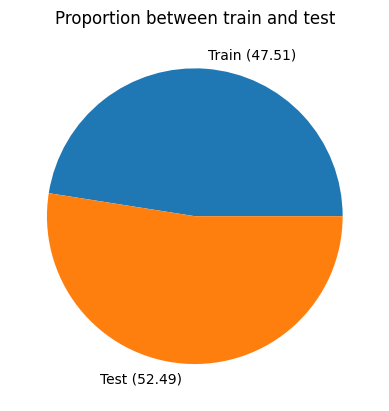

In [4]:
total = len(df_train) + len(df_test)

train_perc = len(df_train) / total
test_perc = len(df_test) / total

percs = [train_perc, test_perc]
labels = [f"Train ({round(train_perc * 100, 2)})", f"Test ({round(test_perc * 100, 2)})"]

fig, ax = plt.subplots()
ax.pie(percs, labels=labels)

plt.title("Proportion between train and test")
plt.show()

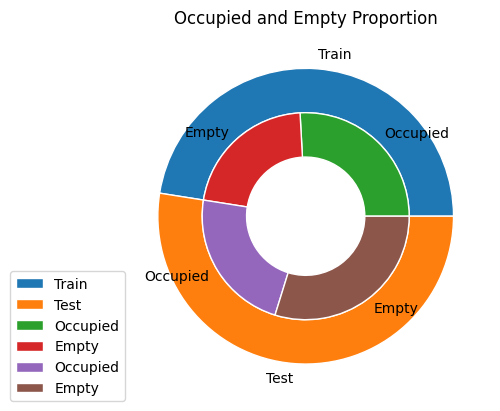

In [5]:
df_train_status = df_train.groupby(df_train["256"])
df_test_status = df_test.groupby(df_test["256"])

train_occupied = len(df_train_status.get_group(1))
train_empty = len(df_train_status.get_group(0))
test_occupied = len(df_test_status.get_group(1))
test_empty = len(df_test_status.get_group(0))

labels_inner = ["Occupied", "Empty", "Occupied", "Empty"]
labels_outer = ["Train", "Test"]
vals = np.array([[train_occupied, train_empty], [test_occupied, test_empty]])

size = 0.3
fig, ax = plt.subplots()
ax.pie(vals.sum(axis=1), radius=1, wedgeprops=dict(width=size, edgecolor='w'), labels=labels_outer)
ax.pie(vals.flatten(), radius=1-size, wedgeprops=dict(width=size, edgecolor='w'), labels=labels_inner)
ax.set(aspect="equal", title='Occupied and Empty Proportion')
plt.legend(loc=(-0.3, 0))
plt.show()

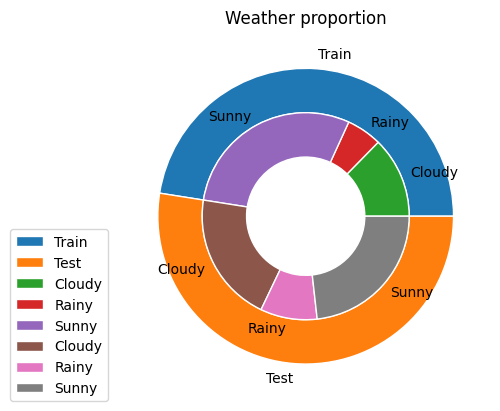

In [6]:
df_train_weather = df_train.groupby(df_train["weather"])
df_test_weather = df_test.groupby(df_test["weather"])

train_cloudy = len(df_train_weather.get_group("Cloudy"))
train_rainy = len(df_train_weather.get_group("Rainy"))
train_sunny = len(df_train_weather.get_group("Sunny"))

test_cloudy = len(df_test_weather.get_group("Cloudy"))
test_rainy = len(df_test_weather.get_group("Rainy"))
test_sunny = len(df_test_weather.get_group("Sunny"))

labels_inner = ["Cloudy", "Rainy", "Sunny", "Cloudy", "Rainy", "Sunny"]
labels_outer = ["Train", "Test"]
vals = np.array([[train_cloudy, train_rainy, train_sunny], [test_cloudy, test_rainy, test_sunny]])


size = 0.3
fig, ax = plt.subplots()
ax.pie(vals.sum(axis=1), radius=1, wedgeprops=dict(width=size, edgecolor='w'), labels=labels_outer)
ax.pie(vals.flatten(), radius=1-size, wedgeprops=dict(width=size, edgecolor='w'), labels=labels_inner)
ax.set(aspect="equal", title='Weather proportion')
plt.legend(loc=(-0.3, 0))
plt.show()

### Saving training and test csv

In [7]:
df_train.to_csv("../features/train.csv", index=False)
df_test.to_csv("../features/test.csv", index=False)